# **Loading the Necessary Datasets**

In [ ]:
# ==========================================================
# IMPORTING ALL REQUIRED LIBRARIES
# Student Dropout Prediction - Random Forest & Bagging Model
# ==========================================================


# -------------------------------
# Data Processing Libraries
# -------------------------------

import pandas as pd
import numpy as np


# -------------------------------
# Data Visualisation Libraries
# -------------------------------

import matplotlib.pyplot as plt
import seaborn as sns


# -------------------------------
# Data Preparation Libraries
# -------------------------------

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler


# -------------------------------
# Machine Learning Models
# -------------------------------

from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier
)

from sklearn.tree import DecisionTreeClassifier


# -------------------------------
# Model Evaluation Metrics
# -------------------------------

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    roc_curve
)


# -------------------------------
# Warning Management
# -------------------------------

import warnings

warnings.filterwarnings("ignore")


# -------------------------------
# Visualisation Configuration
# -------------------------------

sns.set_style("whitegrid")

# **Dataset Loading Steps**

In [ ]:
# ==========================================
# Loading Student Datasets
# ==========================================

# Loading academic and personal information
student_df = pd.read_excel("/content/personal_data.xlsx")

In [ ]:
# Loading VLE engagement information
vle_df = pd.read_csv("/content/vle_data.csv")

# **Combine Both Datasets**

In [ ]:
# ==========================================
# Combining datasets using ID
# ==========================================

combined_df = pd.merge(
    student_df,
    vle_df,
    on="id",
    how="inner"
)


combined_df.head()

,id,age,gender,ethnicity,first_in_family,disability_flag,commuting_distance_km,accommodation_type,financial_support_flag,attendance_rate,...,credits_passed,dropout_risk,vle_logins_per_week,minutes_on_vle_per_week,resources_viewed,video_lectures_watched,forum_posts,quiz_attempts,late_submissions,days_since_last_vle_access
0,200369,56,Female,Black,1,0,14,On-campus,0,86.173486,...,30,0,19,291,38,5,1,1,0,2
1,200370,46,Male,Black,1,0,11,On-campus,0,65.878952,...,45,1,15,626,26,3,2,0,0,11
2,200371,32,Female,White,0,0,9,On-campus,0,96.814505,...,45,0,17,481,30,5,0,1,0,8
3,200372,25,Female,Other,0,0,2,Commuting,0,92.083621,...,30,0,18,646,28,3,1,1,1,3
4,200373,38,Male,Asian,1,0,2,Off-campus,0,94.637350,...,60,1,18,356,26,3,4,2,0,9


In [ ]:
print("Combined Dataset Shape:", combined_df.shape)

Combined Dataset Shape: (500, 21)


## **Check Missing Values**

In [ ]:
combined_df.isnull().sum()

,0
id,0
age,0
gender,0
ethnicity,0
first_in_family,0
disability_flag,0
commuting_distance_km,0
accommodation_type,0
financial_support_flag,0
attendance_rate,0


In [ ]:
# ==========================================
# Duplicate Analysis
# ==========================================

duplicate_records = combined_df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_records)

Number of Duplicate Records: 0


In [ ]:
# ==========================================
# Statistical Overview
# ==========================================

combined_df.describe()

,id,age,first_in_family,disability_flag,commuting_distance_km,financial_support_flag,attendance_rate,avg_assignment_grade,credits_passed,dropout_risk,vle_logins_per_week,minutes_on_vle_per_week,resources_viewed,video_lectures_watched,forum_posts,quiz_attempts,late_submissions,days_since_last_vle_access
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,200618.500000,39.326000,0.252000,0.094000,9.870000,0.258000,79.562033,58.368938,39.150000,0.470000,14.610000,593.79800,29.184000,4.600000,1.012000,1.854000,0.468000,4.878000
std,144.481833,12.200386,0.434596,0.292121,4.897455,0.437972,14.304973,14.770819,16.406274,0.499599,5.013199,196.32419,10.010122,2.692675,0.951666,1.260103,0.699969,3.549128
min,200369.000000,18.000000,0.000000,0.000000,0.000000,0.000000,22.450167,20.365642,0.000000,0.000000,1.000000,20.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,200493.750000,29.000000,0.000000,0.000000,6.000000,0.000000,70.585628,47.974965,30.000000,0.000000,11.000000,468.75000,23.000000,3.000000,0.000000,1.000000,0.000000,2.000000
50%,200618.500000,41.000000,0.000000,0.000000,10.000000,0.000000,80.114294,58.967274,45.000000,0.000000,14.000000,595.50000,29.000000,4.000000,1.000000,2.000000,0.000000,4.000000
75%,200743.250000,50.000000,1.000000,0.000000,13.000000,1.000000,91.678570,67.648289,45.000000,1.000000,18.000000,729.50000,36.000000,6.000000,2.000000,3.000000,1.000000,7.000000
max,200868.000000,59.000000,1.000000,1.000000,27.000000,1.000000,100.000000,100.000000,60.000000,1.000000,28.000000,1129.00000,56.000000,13.000000,5.000000,5.000000,4.000000,16.000000


# **EXPLORATORY DATA ANALYSIS (EDA)**

In [ ]:
# Replace abbreviations with full labels
combined_df['gender'] = combined_df['gender'].replace({
    'F': 'Female',
    'M': 'Male'
})

In [ ]:
# ==========================================
# Gender Based Dropout Calculation
# ==========================================

gender_analysis = (
    combined_df
    .groupby("gender")["dropout_risk"]
    .value_counts()
    .unstack()
)


gender_analysis

dropout_risk,0,1
gender,,
Female,124,108
Male,129,117
Other,12,10


# **OUTLIER ANALYSIS — Attendance Rate**

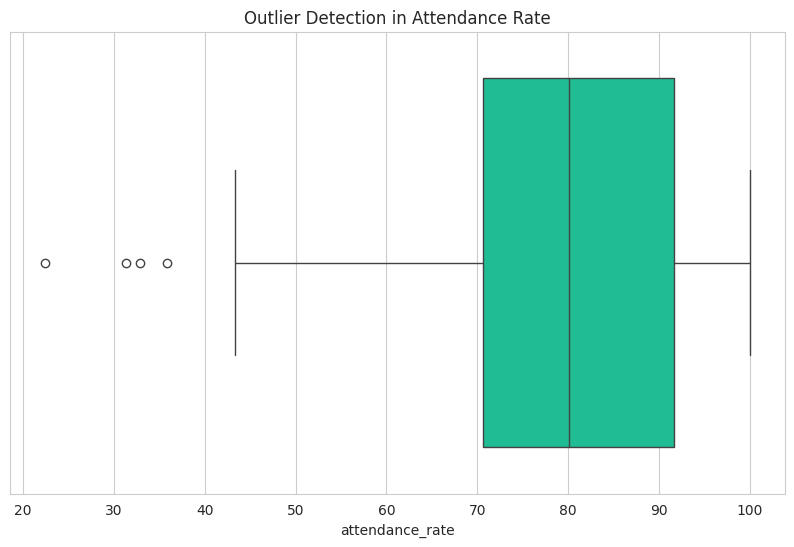

In [ ]:
# ==========================================
# Attendance Outlier Detection
# ==========================================

plt.figure(figsize=(10,6))


sns.boxplot(
    x=combined_df["attendance_rate"],
    color="#06d6a0"
)


plt.title(
    "Outlier Detection in Attendance Rate"
)


plt.show()

# **Descriptive Statistics**

## **Dropout Data Divided by Gender**

In [ ]:
# ============================================
# Gender-wise dropout analysis
# ============================================

gender_dropout = pd.crosstab(
    combined_df['gender'],
    combined_df['dropout_risk']
)

gender_dropout.columns = [
    "Completed Students",
    "Dropped Students"
]

gender_dropout

,Completed Students,Dropped Students
gender,,
Female,124,108
Male,129,117
Other,12,10


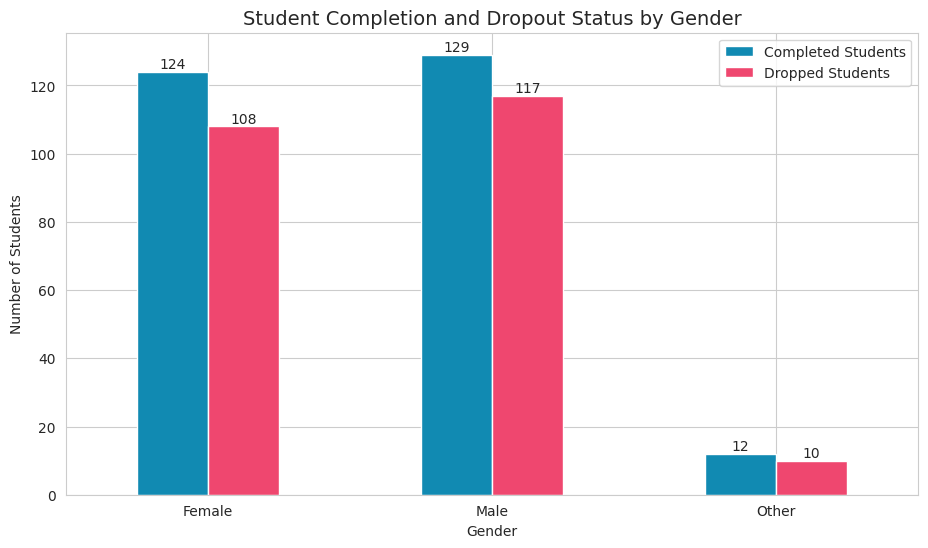

In [ ]:
# ============================================
# Gender dropout visualization
# ============================================

ax = gender_dropout.plot(
    kind='bar',
    figsize=(11,6),
    color=['#118AB2','#EF476F']
)


plt.title(
    "Student Completion and Dropout Status by Gender",
    fontsize=14
)

plt.xlabel("Gender")

plt.ylabel("Number of Students")


for container in ax.containers:
    ax.bar_label(container)


plt.xticks(rotation=0)

plt.legend()

plt.show()

## **Average Age of Students**

In [ ]:
# ============================================
# Average age calculation
# ============================================

mean_age = combined_df['age'].agg(['mean','min','max'])

mean_age

,age
mean,39.326
min,18.000
max,59.000


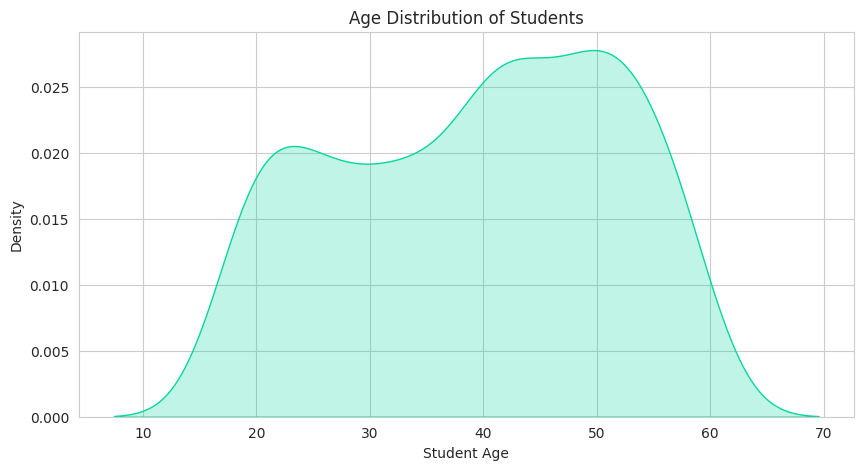

In [ ]:
plt.figure(figsize=(10,5))


sns.kdeplot(
    combined_df['age'],
    fill=True,
    color="#06D6A0"
)


plt.title(
    "Age Distribution of Students"
)

plt.xlabel("Student Age")

plt.ylabel("Density")


plt.show()

# **Average Minutes on VLE per Week**

In [ ]:
# ============================================
# VLE engagement statistics
# ============================================

vle_summary = combined_df[
    'minutes_on_vle_per_week'
].describe()


vle_summary

,minutes_on_vle_per_week
count,500.00000
mean,593.79800
std,196.32419
min,20.00000
25%,468.75000
50%,595.50000
75%,729.50000
max,1129.00000


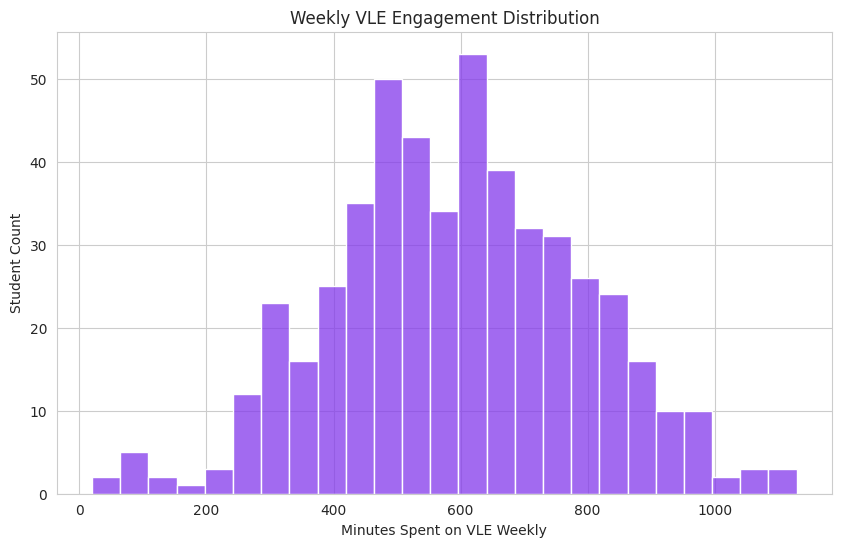

In [ ]:
plt.figure(figsize=(10,6))


sns.histplot(
    combined_df['minutes_on_vle_per_week'],
    bins=25,
    color="#8338EC"
)


plt.title(
    "Weekly VLE Engagement Distribution"
)

plt.xlabel(
    "Minutes Spent on VLE Weekly"
)

plt.ylabel(
    "Student Count"
)


plt.show()

# **Distribution of Attendance Rate**

In [ ]:
# ============================================
# Attendance calculation
# ============================================

attendance_statistics = combined_df[
    'attendance_rate'
].agg(
    ['mean','median','std']
)


attendance_statistics

,attendance_rate
mean,79.562033
median,80.114294
std,14.304973


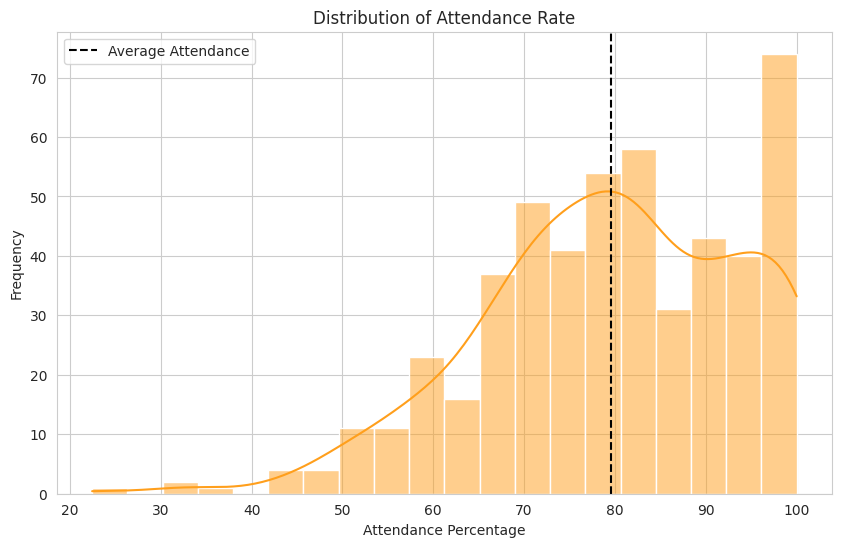

In [ ]:
plt.figure(figsize=(10,6))


sns.histplot(
    combined_df['attendance_rate'],
    bins=20,
    kde=True,
    color="#FF9F1C"
)


plt.axvline(
    combined_df['attendance_rate'].mean(),
    color='black',
    linestyle='--',
    label="Average Attendance"
)


plt.title(
    "Distribution of Attendance Rate"
)

plt.xlabel(
    "Attendance Percentage"
)

plt.ylabel(
    "Frequency"
)


plt.legend()

plt.show()

# **Distribution of Assignment Grade**

In [ ]:
# ============================================
# Assignment grade analysis
# ============================================

grade_statistics = combined_df[
    'avg_assignment_grade'
].agg(
    ['mean','median','min','max']
)


grade_statistics

,avg_assignment_grade
mean,58.368938
median,58.967274
min,20.365642
max,100.000000


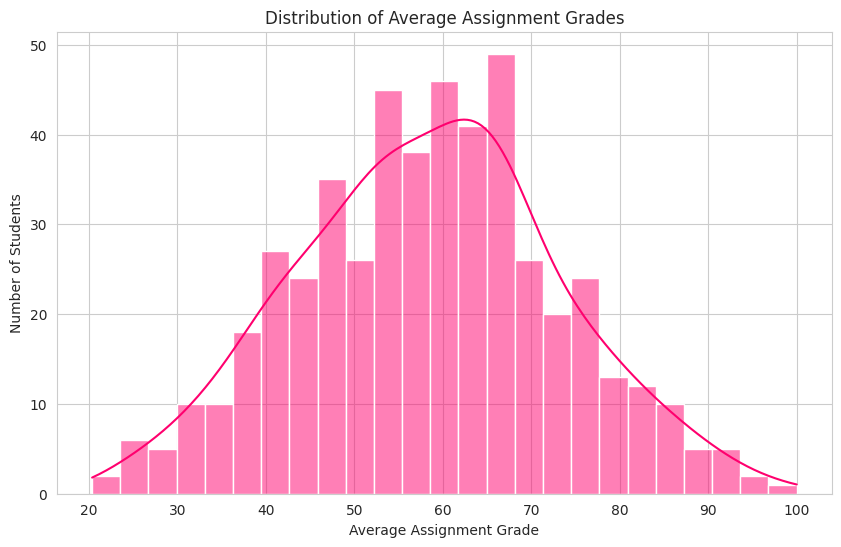

In [ ]:
plt.figure(figsize=(10,6))


sns.histplot(
    combined_df['avg_assignment_grade'],
    bins=25,
    kde=True,
    color="#FF006E"
)


plt.title(
    "Distribution of Average Assignment Grades"
)

plt.xlabel(
    "Average Assignment Grade"
)

plt.ylabel(
    "Number of Students"
)


plt.show()

# **Attendance Rate by Accommodation Type**

In [ ]:
# ============================================
# Accommodation attendance comparison
# ============================================

attendance_accommodation = (
    combined_df
    .groupby('accommodation_type')
    ['attendance_rate']
    .mean()
    .sort_values()
)


attendance_accommodation

,attendance_rate
accommodation_type,
Off-campus,78.903997
On-campus,78.921377
Commuting,80.856679


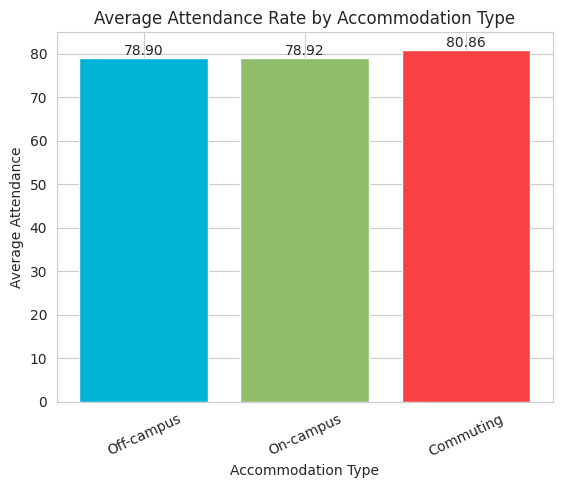

In [ ]:
bars = plt.bar(
    attendance_accommodation.index,
    attendance_accommodation.values,
    color=[
        '#00B4D8',
        '#90BE6D',
        '#F94144'
    ]
)


plt.title(
    "Average Attendance Rate by Accommodation Type"
)


plt.xlabel(
    "Accommodation Type"
)


plt.ylabel(
    "Average Attendance"
)


plt.bar_label(
    bars,
    fmt="%.2f"
)


plt.xticks(rotation=25)


plt.show()

# **Relationship Between Commuting Distance and Dropout**

In [ ]:
# ============================================
# Distance and dropout relationship
# ============================================

distance_dropout = (
    combined_df
    .groupby('dropout_risk')
    ['commuting_distance_km']
    .mean()
)


distance_dropout

,commuting_distance_km
dropout_risk,
0,9.807547
1,9.940426


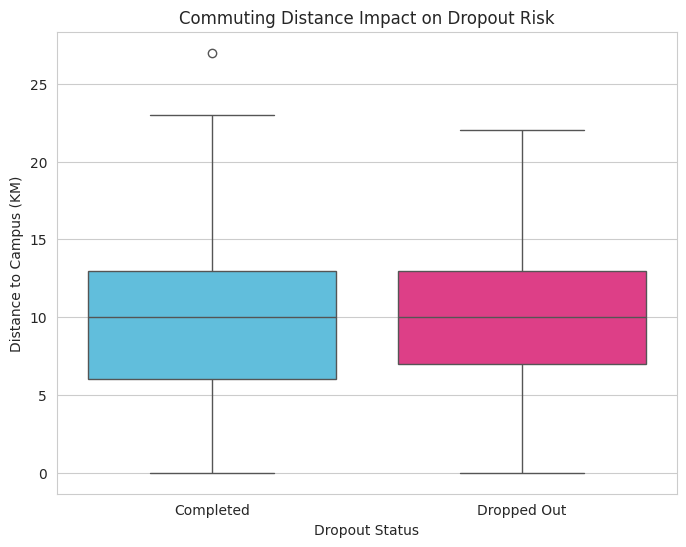

In [ ]:
plt.figure(figsize=(8,6))


sns.boxplot(
    x='dropout_risk',
    y='commuting_distance_km',
    data=combined_df,
    palette=['#4CC9F0','#F72585']
)


plt.title(
    "Commuting Distance Impact on Dropout Risk"
)


plt.xlabel(
    "Dropout Status"
)


plt.ylabel(
    "Distance to Campus (KM)"
)


plt.xticks(
    [0,1],
    ['Completed','Dropped Out']
)


plt.show()

# **Dropout Numbers by Accommodation Type**

In [ ]:
# ============================================
# Dropout count by accommodation
# ============================================

accommodation_dropout = (
    combined_df[
        combined_df['dropout_risk']==1
    ]
    .groupby('accommodation_type')
    .size()
)


accommodation_dropout

,0
accommodation_type,
Commuting,76
Off-campus,78
On-campus,81


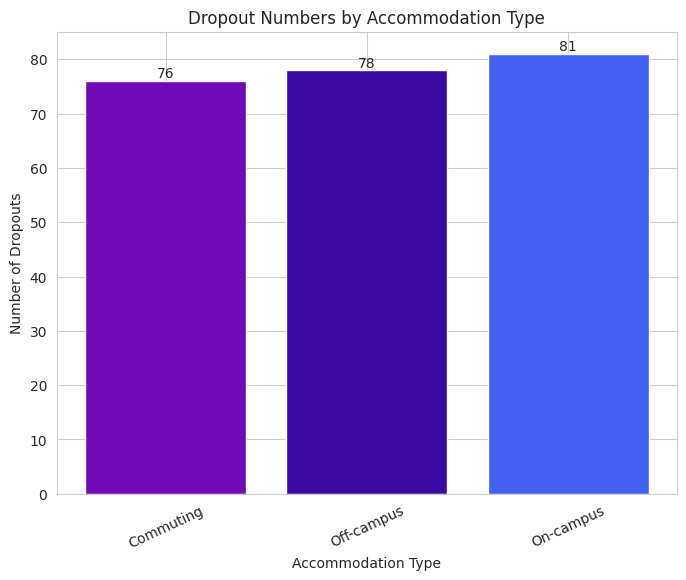

In [ ]:
plt.figure(figsize=(8,6))


bars = plt.bar(
    accommodation_dropout.index,
    accommodation_dropout.values,
    color=[
        '#7209B7',
        '#3A0CA3',
        '#4361EE'
    ]
)


plt.title(
    "Dropout Numbers by Accommodation Type"
)


plt.xlabel(
    "Accommodation Type"
)


plt.ylabel(
    "Number of Dropouts"
)


plt.bar_label(
    bars
)


plt.xticks(rotation=25)


plt.show()

# **Relationship Between Assignment Grade and Late Submissions**

In [ ]:
# ============================================
# Correlation analysis
# ============================================

assignment_late_relation = combined_df[
    [
        'avg_assignment_grade',
        'late_submissions'
    ]
].corr()


assignment_late_relation

,avg_assignment_grade,late_submissions
avg_assignment_grade,1.000000,0.041995
late_submissions,0.041995,1.000000


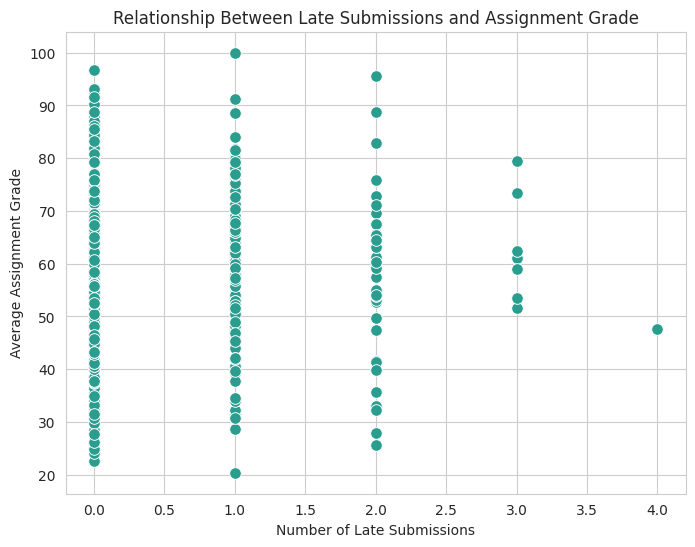

In [ ]:
plt.figure(figsize=(8,6))


sns.scatterplot(
    data=combined_df,
    x='late_submissions',
    y='avg_assignment_grade',
    color="#2A9D8F",
    s=70
)


plt.title(
    "Relationship Between Late Submissions and Assignment Grade"
)


plt.xlabel(
    "Number of Late Submissions"
)


plt.ylabel(
    "Average Assignment Grade"
)


plt.show()

# **Correlation Heatmap**

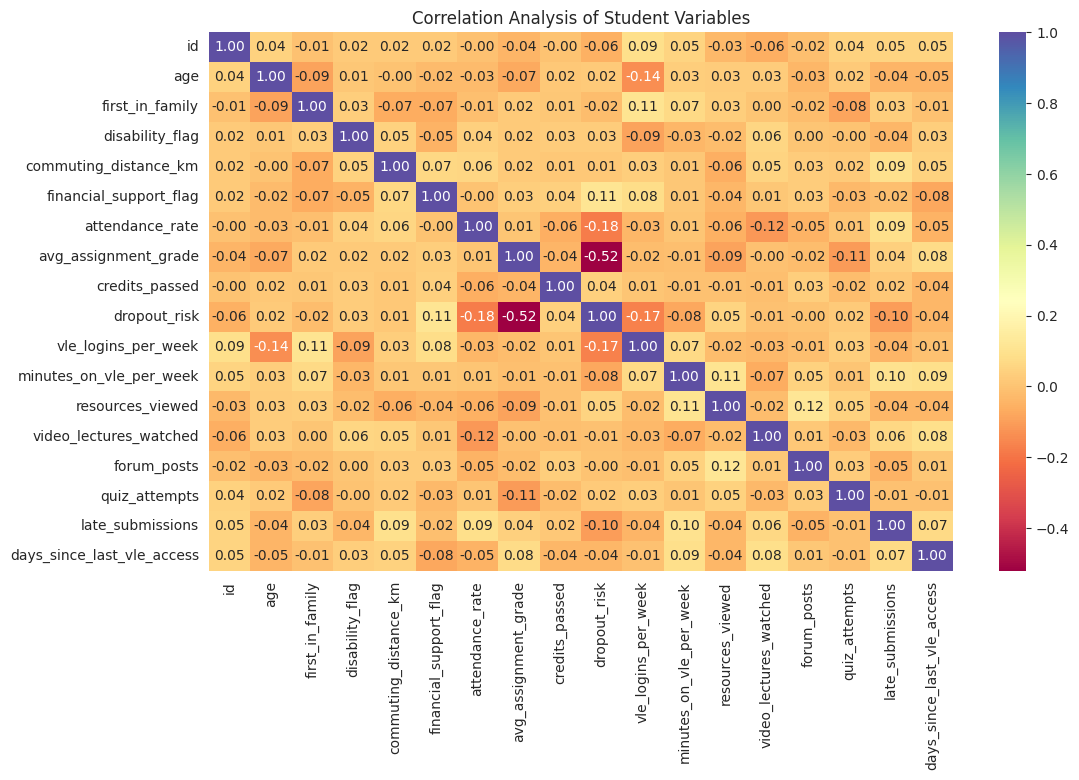

In [ ]:
plt.figure(figsize=(12,7))


numeric_data = combined_df.select_dtypes(
    include=np.number
)


sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="Spectral",
    fmt=".2f"
)


plt.title(
    "Correlation Analysis of Student Variables"
)


plt.show()

# **Define Features and Target Variable**

In [ ]:
# ==========================================
# Feature and Target Separation
# ==========================================

X = combined_df.drop(
    'dropout_risk',
    axis=1
)


y = combined_df['dropout_risk']


print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Shape: (500, 20)
Target Shape: (500,)


# **Convert Categorical Variables**

In [ ]:
# ==========================================
# Encoding categorical features
# ==========================================

categorical_features = X.select_dtypes(
    include=['object']
).columns


print(
    "Categorical Columns:",
    list(categorical_features)
)

Categorical Columns: ['gender', 'ethnicity', 'accommodation_type']


In [ ]:
# One-hot encoding

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)


print(
    "Encoded Dataset Shape:",
    X_encoded.shape
)

Encoded Dataset Shape: (500, 28)


# **Train Test Split**

In [ ]:
# ==========================================
# Splitting dataset
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=25,
    stratify=y
)


print(
    "Training Data:",
    X_train.shape
)


print(
    "Testing Data:",
    X_test.shape
)

Training Data: (400, 28)
Testing Data: (100, 28)


# **Feature Scaling**

In [ ]:
# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)


print("Scaling completed")

Scaling completed


# **Train Random Forest Model**

In [ ]:
# ==========================================
# Random Forest Training
# ==========================================

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    random_state=25
)


rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=8, n_estimators=150, random_state=25)

# **Random Forest Prediction**

In [ ]:
# ==========================================
# Predictions
# ==========================================

rf_prediction = rf_model.predict(
    X_test
)


rf_probability = rf_model.predict_proba(
    X_test
)[:,1]

# **Random Forest Accuracy**

In [ ]:
# ==========================================
# Accuracy Score
# ==========================================

rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)


print(
    "Random Forest Accuracy:",
    round(rf_accuracy,4)
)

Random Forest Accuracy: 0.96


# **Random Forest Classification Report**

In [ ]:
# ==========================================
# Classification Report
# ==========================================

print(
    classification_report(
        y_test,
        rf_prediction
    )
)

              precision    recall  f1-score   support

           0       0.93      1.00      0.96        53
           1       1.00      0.91      0.96        47

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



# **Random Forest Log Loss**

In [ ]:
# ==========================================
# Log Loss Calculation
# ==========================================

rf_logloss = log_loss(
    y_test,
    rf_probability
)


print(
    "Random Forest Log Loss:",
    round(rf_logloss,4)
)

Random Forest Log Loss: 0.2674


# **Random Forest Confusion Matrix**

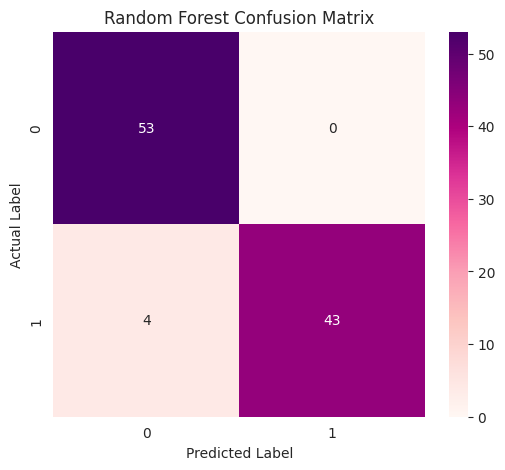

In [ ]:
# ==========================================
# Confusion Matrix
# ==========================================

rf_cm = confusion_matrix(
    y_test,
    rf_prediction
)


plt.figure(figsize=(6,5))


sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap="RdPu"
)


plt.title(
    "Random Forest Confusion Matrix"
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "Actual Label"
)


plt.show()

# **Random Forest ROC-AUC Curve**

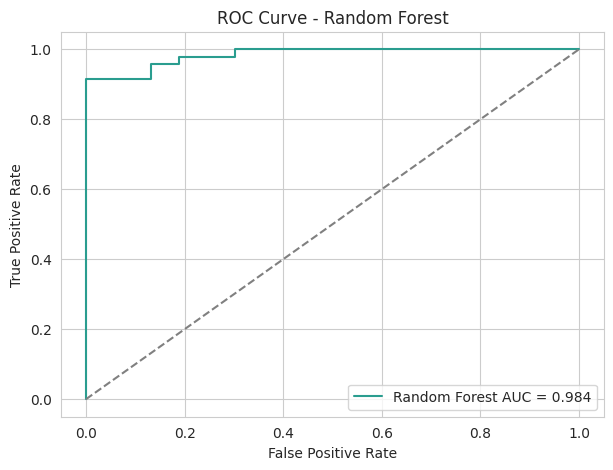

In [ ]:
# ==========================================
# ROC-AUC Curve
# ==========================================

rf_fpr, rf_tpr, threshold = roc_curve(
    y_test,
    rf_probability
)


rf_auc = roc_auc_score(
    y_test,
    rf_probability
)


plt.figure(figsize=(7,5))


plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest AUC = {rf_auc:.3f}",
    color="#2A9D8F"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey"
)


plt.title(
    "ROC Curve - Random Forest"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.legend()

plt.show()

# **Train Bagging Model**

In [ ]:
# ==========================================
# Bagging Classifier Training
# ==========================================

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=25
)


bag_model.fit(
    X_train,
    y_train
)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=25)

# **Bagging Predictions**

In [ ]:
# ==========================================
# Bagging Predictions
# ==========================================

bag_prediction = bag_model.predict(
    X_test
)


bag_probability = bag_model.predict_proba(
    X_test
)[:,1]

# **Bagging Accuracy Score**

In [ ]:
# ==========================================
# Accuracy
# ==========================================

bag_accuracy = accuracy_score(
    y_test,
    bag_prediction
)


print(
    "Bagging Accuracy:",
    round(bag_accuracy,4)
)

Bagging Accuracy: 0.96


# **Bagging Classification Report**

In [ ]:
# ==========================================
# Classification Report
# ==========================================

print(
    classification_report(
        y_test,
        bag_prediction
    )
)

              precision    recall  f1-score   support

           0       0.93      1.00      0.96        53
           1       1.00      0.91      0.96        47

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



# **Bagging Log Loss**

In [ ]:
# ==========================================
# Log Loss
# ==========================================

bag_logloss = log_loss(
    y_test,
    bag_probability
)


print(
    "Bagging Log Loss:",
    round(bag_logloss,4)
)

Bagging Log Loss: 0.0758


# **Bagging Confusion Matrix**

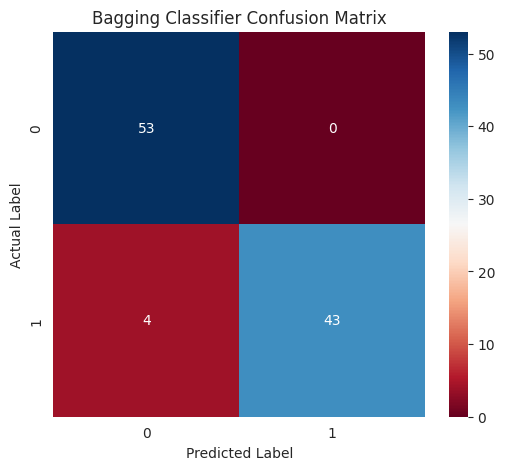

In [ ]:
# ==========================================
# Confusion Matrix
# ==========================================

bag_cm = confusion_matrix(
    y_test,
    bag_prediction
)


plt.figure(figsize=(6,5))


sns.heatmap(
    bag_cm,
    annot=True,
    fmt='d',
    cmap="RdBu"
)


plt.title(
    "Bagging Classifier Confusion Matrix"
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "Actual Label"
)


plt.show()

# **Bagging ROC-AUC Curve**

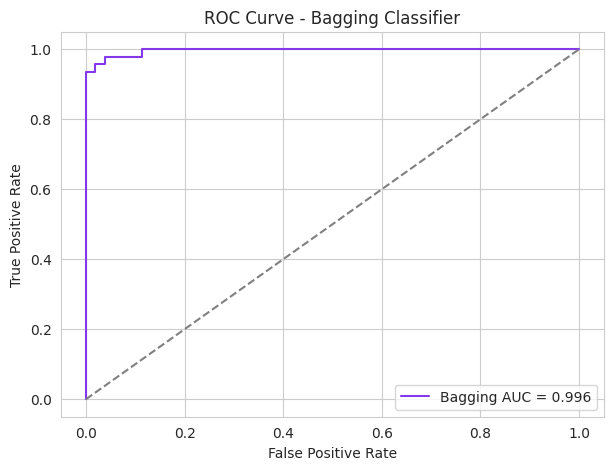

In [ ]:
# ==========================================
# ROC Curve
# ==========================================

bag_fpr, bag_tpr, threshold = roc_curve(
    y_test,
    bag_probability
)


bag_auc = roc_auc_score(
    y_test,
    bag_probability
)


plt.figure(figsize=(7,5))


plt.plot(
    bag_fpr,
    bag_tpr,
    label=f"Bagging AUC = {bag_auc:.3f}",
    color="#8338EC"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey"
)


plt.title(
    "ROC Curve - Bagging Classifier"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.legend()

plt.show()

# **Final Model Comparison Table**

In [ ]:
# ==========================================
# Model Performance Comparison
# ==========================================

model_results = pd.DataFrame({

    "Model":[
        "Random Forest",
        "Bagging Classifier"
    ],

    "Accuracy":[
        rf_accuracy,
        bag_accuracy
    ],

    "Log Loss":[
        rf_logloss,
        bag_logloss
    ],

    "ROC-AUC":[
        rf_auc,
        bag_auc
    ]

})


model_results

,Model,Accuracy,Log Loss,ROC-AUC
0,Random Forest,0.96,0.267354,0.983942
1,Bagging Classifier,0.96,0.075789,0.996387
